<a href="https://colab.research.google.com/github/jfar/cryptobot/blob/main/risk_management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## [Asset risk management](https://www.codearmo.com/blog/sharpe-sortino-and-calmar-ratios-python)

In [ ]:
from pandas_datareader import data as pdr
import yfinance as yf
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [ ]:
yf.pdr_override()

start = dt.datetime(2013, 1, 1)
end = dt.datetime(2020, 10, 1)

tickers = ['AAPL', 'AMZN', 'MSFT', 'GOOGL','META']
stocks = pdr.get_data_yahoo(tickers,start,end)['Adj Close']

[*********************100%***********************]  5 of 5 completed


,AAPL,AMZN,GOOGL,META,MSFT,Port
Date,,,,,,
2020-09-30,6.774616,12.237106,4.048765,9.353571,9.049771,8.804575


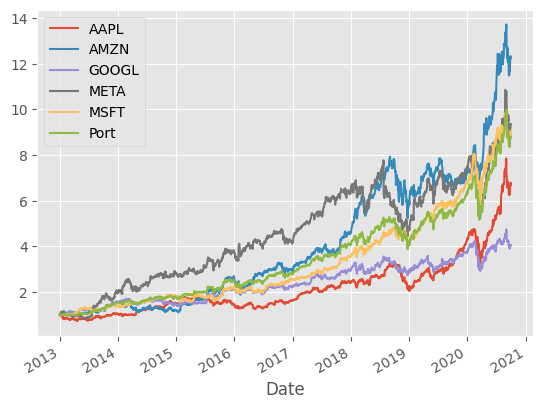

In [ ]:
df = stocks.pct_change().dropna()
df['Port'] = df.mean(axis=1) # 20% apple, ... , 20% facebook
(df+1).cumprod().plot()

(df+1).cumprod()[-1:]

<Axes: >

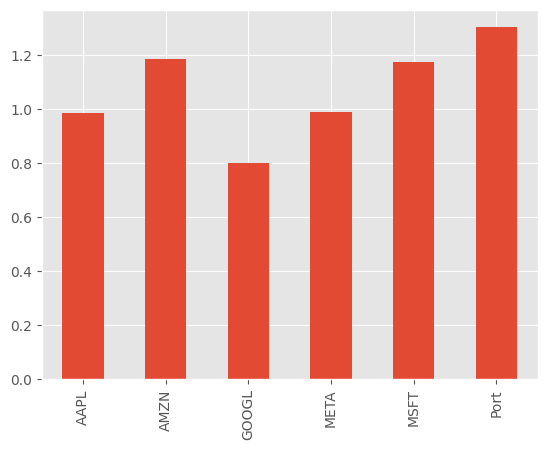

In [ ]:
def sharpe_ratio(return_series, N, rf):
    mean = return_series.mean() * N -rf
    sigma = return_series.std() * np.sqrt(N)
    return mean / sigma

N = 255 #255 trading days in a year
rf =0.01 #1% risk free rate
sharpes = df.apply(sharpe_ratio, args=(N,rf,),axis=0)

sharpes.plot.bar()

Text(0, 0.5, 'Sortino Ratio')

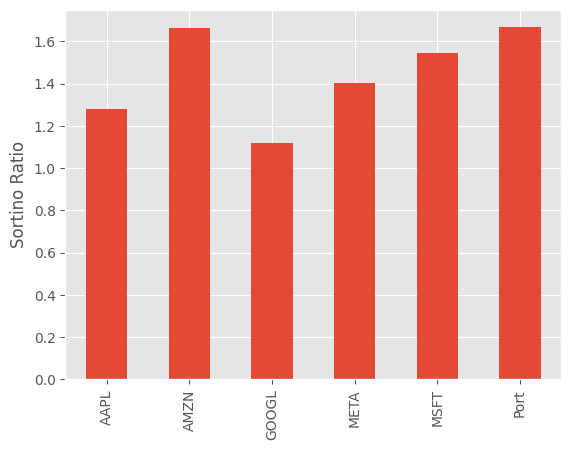

In [ ]:
def sortino_ratio(series, N,rf):
    mean = series.mean() * N -rf
    std_neg = series[series<0].std()*np.sqrt(N)
    return mean/std_neg


sortinos = df.apply(sortino_ratio, args=(N,rf,), axis=0 )
sortinos.plot.bar()
plt.ylabel('Sortino Ratio')

Text(0.5, 1.0, 'Max Drawdown')

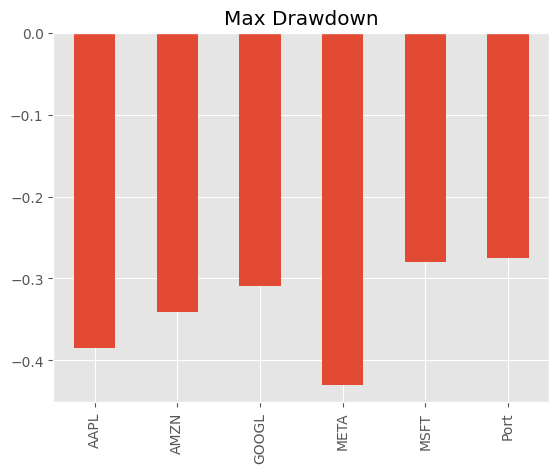

In [ ]:
def max_drawdown(return_series):
    comp_ret = (return_series+1).cumprod()
    peak = comp_ret.cummax()
    dd = (comp_ret/peak)-1
    return dd.min()


max_drawdowns = df.apply(max_drawdown,axis=0)
max_drawdowns.plot.bar()
plt.title('Max Drawdown')

Text(0, 0.5, 'Calmar ratio')

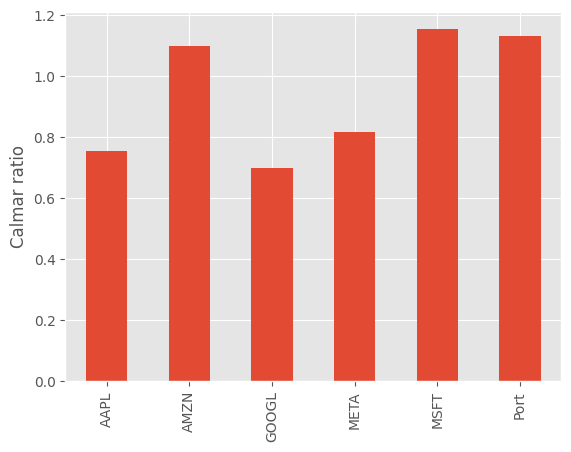

In [ ]:
calmars = df.mean()*255/abs(max_drawdowns)

calmars.plot.bar()
plt.ylabel('Calmar ratio')

## Talib

In [ ]:
def candlesticks(df, w=1, format='%d-%m-%Y'):
  prices = copy(df.dropna())
  prices.reset_index(inplace=True)
  if 'Date' in prices:
    prices['Date'] = prices['Date'].apply(mpl_dates.date2num)
  else:
    prices['Datetime'] = prices['Datetime'].apply(mpl_dates.date2num)

  fig, ax = plt.subplots(figsize=[10,7])
  candlestick_ohlc(ax, prices.values, width=w, colorup='green',colordown='red',alpha=0.8)
  date_format = mpl_dates.DateFormatter(format)
  ax.xaxis.set_major_formatter(date_format)
  fig.autofmt_xdate()

### Install talib

In [ ]:
# url = 'https://anaconda.org/conda-forge/libta-lib/0.4.0/download/linux-64/libta-lib-0.4.0-h166bdaf_1.tar.bz2'
# !curl -L $url | tar xj -C /usr/lib/x86_64-linux-gnu/ lib --strip-components=1
url = 'https://anaconda.org/conda-forge/ta-lib/0.4.19/download/linux-64/ta-lib-0.4.19-py39hd257fcd_4.tar.bz2'
!curl -L $url | tar xj -C /usr/local/lib/python3.9/dist-packages/ lib/python3.9/site-packages/talib --strip-components=3

In [ ]:
!pip install yfinance
!pip install mpl_finance

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from mpl_finance import candlestick_ohlc
import matplotlib.dates as mpl_dates
from copy import copy
import talib
from sklearn.linear_model import LinearRegression, LogisticRegression

plt.style.use('ggplot')

In [ ]:
df = yf.download('SPY').reset_index()

[*********************100%***********************]  1 of 1 completed


In [ ]:
results = []
cols = []
for attr in dir(talib):
  if attr[:3] == 'CDL':
    res = getattr(talib,attr)(df.Open,df.High,df.Low,df.Close)
    results.append(res)
patterns = pd.DataFrame(results).T
df['all_pats'] = patterns.sum(axis=1)
df

,Date,Open,High,Low,Close,Adj Close,Volume,all_pats
0,1993-01-29,43.968750,43.968750,43.750000,43.937500,25.122356,1003200,0
1,1993-02-01,43.968750,44.250000,43.968750,44.250000,25.301022,480500,0
2,1993-02-02,44.218750,44.375000,44.125000,44.343750,25.354622,201300,0
3,1993-02-03,44.406250,44.843750,44.375000,44.812500,25.622637,529400,0
4,1993-02-04,44.968750,45.093750,44.468750,45.000000,25.729856,531500,0
...,...,...,...,...,...,...,...,...
7610,2023-04-20,411.209991,413.700012,410.269989,411.880005,411.880005,75840400,100
7611,2023-04-21,412.190002,412.679993,410.170013,412.200012,412.200012,73436100,400
7612,2023-04-24,411.989990,413.070007,410.600006,412.630005,412.630005,64332100,0
7613,2023-04-25,410.579987,411.160004,406.019989,406.079987,406.079987,97586300,-200


Text(0.5, 1.0, 'slope: -9.151511430810287e-07')

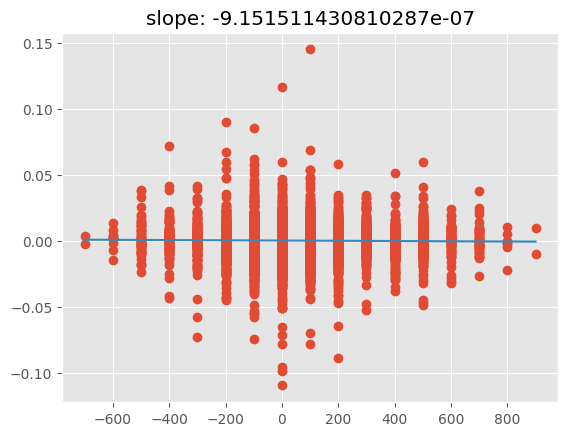

In [ ]:
sft = -1
df.loc[:,'returns'] = df.Close.pct_change().shift(sft)
plt.plot(df.all_pats,df.returns,'o')
m = np.polyfit(df.all_pats.iloc[sft+1:-1],df.returns.iloc[sft+1:-1],1)
xx = np.linspace(min(df.all_pats),max(df.all_pats),200)
yy = np.polyval(m,xx)
plt.plot(xx,yy)
plt.title('slope: %s' %m[0])

In [ ]:
np.sign([-10,5,12,-2,0])

array([-1,  1,  1, -1,  0])

In [ ]:
%cd root

/root


In [ ]:
%ls -la /usr/local/lib/python3.9/dist-packages/

In [ ]:
%ls -la /usr/lib/x86_64-linux-gnu/